Χρησιμοποιώντας Convolutional επίπεδα, τόσο ο Generator (για να ζωγραφίζει) όσο και ο Critic/Classifier (για να αξιολογούν) "βλέπουν" τις εικόνες ως πραγματικά δισδιάστατα σχήματα και όχι ως μια επίπεδη γραμμή αριθμών. Αυτό είναι το μυστικό των σύγχρονων DCGANs (Deep Convolutional GANs)!

Σου παραθέτω όλον τον κώδικα από την αρχή, Έχω αναβαθμίσει σε αρχιτεκτονική CNN και τον Classifier (Solver) και το WGAN-GP.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.autograd as autograd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import copy

In [2]:
BATCH_SIZE = 64

# Κανονικοποίηση στο [-1, 1] για συνεργασία με την Tanh() του Generator
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("Κατέβασμα δεδομένων...")
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

Κατέβασμα δεδομένων...


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.86MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.77MB/s]


In [3]:
def get_task_data(dataset, classes):
    targets = dataset.targets.numpy()
    mask = np.isin(targets, classes)
    indices = np.where(mask)[0]
    return Subset(dataset, indices)

tasks = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
train_loaders = []
test_loaders = []

for task_classes in tasks:
    task_train_subset = get_task_data(train_dataset, task_classes)
    task_test_subset = get_task_data(test_dataset, task_classes)
    train_loader = DataLoader(task_train_subset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(task_test_subset, batch_size=BATCH_SIZE, shuffle=False)
    train_loaders.append(train_loader)
    test_loaders.append(test_loader)

print("\n--- Έτοιμο το Split-MNIST! ---")
for i, loader in enumerate(train_loaders):
    print(f"Task {i+1} (Ψηφία {tasks[i]}): {len(loader.dataset)} εικόνες εκπαίδευσης")


--- Έτοιμο το Split-MNIST! ---
Task 1 (Ψηφία [0, 1]): 12665 εικόνες εκπαίδευσης
Task 2 (Ψηφία [2, 3]): 12089 εικόνες εκπαίδευσης
Task 3 (Ψηφία [4, 5]): 11263 εικόνες εκπαίδευσης
Task 4 (Ψηφία [6, 7]): 12183 εικόνες εκπαίδευσης
Task 5 (Ψηφία [8, 9]): 11800 εικόνες εκπαίδευσης


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Το μοντέλο θα τρέξει σε: {device}")

class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # Conv2d: (Είσοδος channels, Έξοδος channels, Kernel size, Stride, Padding)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # Μετά από 2 MaxPools η εικόνα 28x28 γίνεται 7x7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # x μπαίνει ως [Batch, 1, 28, 28]
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7) # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def evaluate_model(model, test_loaders, current_task_idx):
    model.eval()
    accuracies = []
    with torch.no_grad():
        for i in range(current_task_idx + 1):
            correct = 0
            total = 0
            for data, target in test_loaders[i]:
                data, target = data.to(device), target.to(device)
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
            acc = 100 * correct / total
            accuracies.append(acc)
    return accuracies

criterion_class = nn.CrossEntropyLoss()

Το μοντέλο θα τρέξει σε: cuda


In [5]:
LATENT_DIM = 100
NUM_CLASSES = 10

class CondCNNGenerator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES):
        super(CondCNNGenerator, self).__init__()
        # Το label μετατρέπεται σε διάνυσμα μεγέθους 10
        self.label_emb = nn.Embedding(num_classes, 10)

        # Αρχικό spatial size θα είναι 7x7. (Άρα 128 φίλτρα * 7 * 7)
        self.l1 = nn.Sequential(nn.Linear(latent_dim + 10, 128 * 7 * 7))

        self.conv_blocks = nn.Sequential(
            nn.InstanceNorm2d(128), # Το InstanceNorm προτιμάται έναντι του BatchNorm στα WGANs
            # Μεγεθύνει από 7x7 σε 14x14
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            # Μεγεθύνει από 14x14 σε 28x28 (Μέγεθος MNIST)
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, noise, labels):
        c = self.label_emb(labels)
        # Ενώνουμε τον θόρυβο με την ετικέτα
        gen_input = torch.cat((noise, c), dim=-1)
        out = self.l1(gen_input)
        # Το κάνουμε εικόνα 7x7 με 128 κανάλια
        out = out.view(out.shape[0], 128, 7, 7)
        img = self.conv_blocks(out)
        return img

class CondCNNCritic(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(CondCNNCritic, self).__init__()
        # Η ετικέτα απλώνεται ώστε να γίνει ένα επιπλέον "κανάλι" (image plane) 28x28
        self.label_emb = nn.Embedding(num_classes, 28 * 28)

        self.conv_blocks = nn.Sequential(
            # Είσοδος: 2 κανάλια (1 η εικόνα + 1 το label)
            nn.Conv2d(2, 64, kernel_size=4, stride=2, padding=1), # -> 14x14
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # -> 7x7
            nn.LeakyReLU(0.2, inplace=True),
        )
        # Βγάζει ΕΝΑ πραγματικό νούμερο (όχι Sigmoid)
        self.adv_layer = nn.Linear(128 * 7 * 7, 1)

    def forward(self, img, labels):
        # Μετατρέπουμε την ετικέτα σε επίπεδο 28x28 και το "κολλάμε" πίσω από την εικόνα
        c = self.label_emb(labels).view(labels.size(0), 1, 28, 28)
        x = torch.cat((img, c), dim=1)

        out = self.conv_blocks(x)
        out = out.view(out.shape[0], -1)
        validity = self.adv_layer(out)
        return validity

def compute_gradient_penalty(critic, real_samples, fake_samples, labels):
    # Συνάρτηση ποινής WGAN-GP (Τώρα προσαρμοσμένη για 4D Εικόνες)
    alpha = torch.rand(real_samples.size(0), 1, 1, 1).to(device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)

    d_interpolates = critic(interpolates, labels)
    fake = torch.ones(real_samples.size(0), 1).to(device)

    gradients = autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

In [6]:
gr_classifier = CNNClassifier().to(device)
gr_G = CondCNNGenerator().to(device)
gr_C = CondCNNCritic().to(device)

opt_classifier = optim.Adam(gr_classifier.parameters(), lr=0.001)

# Παράμετροι Adam (beta1=0.0, beta2=0.9) - Κλασικές επιλογές για WGAN-GP
opt_G = optim.Adam(gr_G.parameters(), lr=0.0001, betas=(0.0, 0.9))
opt_C = optim.Adam(gr_C.parameters(), lr=0.0001, betas=(0.0, 0.9))

prev_classifier = None
prev_G = None

# Βασικές ρυθμίσεις
EPOCHS_PER_TASK = 15
LAMBDA_GP = 10
CRITIC_ITERATIONS = 5

print("\n--- Ξεκινάει η Εκπαίδευση με GENERATIVE REPLAY (CNN WGAN-GP) ---")

gr_acc_matrix = []  # Αποθήκευση για τα τελικά plots
for task_idx, train_loader in enumerate(train_loaders):
    print(f"\nΕκπαίδευση στο Task {task_idx + 1} (Ψηφία {tasks[task_idx]})...")
    gr_classifier.train()
    gr_G.train()
    gr_C.train()

    past_classes = [c for past_task in tasks[:task_idx] for c in past_task]

    for epoch in range(EPOCHS_PER_TASK):
        for real_data, real_target in train_loader:
            real_data, real_target = real_data.to(device), real_target.to(device)
            batch_size = real_data.size(0)

            # --- 1. GENERATIVE REPLAY (Δυναμικό Buffer) ---
            if prev_G is not None and prev_classifier is not None:
                fake_batch_size = batch_size * task_idx

                with torch.no_grad():
                    z_prev = torch.randn(fake_batch_size, LATENT_DIM).to(device)
                    y_prev_fake = torch.tensor(np.random.choice(past_classes, fake_batch_size)).to(device)

                    fake_prev_data = prev_G(z_prev, y_prev_fake).detach()

                    # Scholar (Classifier) ονομάζει τα fake data
                    fake_outputs = prev_classifier(fake_prev_data)
                    _, fake_prev_target = torch.max(fake_outputs.data, 1)

                combined_data = torch.cat([real_data, fake_prev_data])
                combined_target = torch.cat([real_target, fake_prev_target])
            else:
                combined_data = real_data
                combined_target = real_target

            total_batch_size = combined_data.size(0)

            # --- 2. ΕΚΠΑΙΔΕΥΣΗ TOY CNN CLASSIFIER ---
            opt_classifier.zero_grad()
            outputs = gr_classifier(combined_data)
            loss_class = criterion_class(outputs, combined_target)
            loss_class.backward()
            opt_classifier.step()

            # --- 3. ΕΚΠΑΙΔΕΥΣΗ WGAN-GP (CNNs) ---

            # Βήμα Α: Critic
            for _ in range(CRITIC_ITERATIONS):
                opt_C.zero_grad()

                z_curr = torch.randn(total_batch_size, LATENT_DIM).to(device)
                fake_imgs = gr_G(z_curr, combined_target)

                real_validity = gr_C(combined_data, combined_target)
                fake_validity = gr_C(fake_imgs.detach(), combined_target)

                gp = compute_gradient_penalty(gr_C, combined_data, fake_imgs.detach(), combined_target)

                loss_C = -torch.mean(real_validity) + torch.mean(fake_validity) + LAMBDA_GP * gp
                loss_C.backward()
                opt_C.step()

            # Βήμα Β: Generator
            opt_G.zero_grad()
            z_curr = torch.randn(total_batch_size, LATENT_DIM).to(device)
            fake_imgs = gr_G(z_curr, combined_target)

            fake_validity = gr_C(fake_imgs, combined_target)
            loss_G = -torch.mean(fake_validity)

            loss_G.backward()
            opt_G.step()

    # Αξιολόγηση με το CNN Classifier!
    accs = evaluate_model(gr_classifier, test_loaders, task_idx)
    gr_acc_matrix.append(accs)  # Αποθήκευση για plots
    print(f"Αποτελέσματα μετά το Task {task_idx + 1}:")
    for i, acc in enumerate(accs):
        print(f" -> Ακρίβεια στο Task {i + 1}: {acc:.2f}%")

    # Αποθήκευση Αντιγράφων
    prev_classifier = copy.deepcopy(gr_classifier)
    prev_classifier.eval()

    prev_G = copy.deepcopy(gr_G)
    prev_G.eval()


--- Ξεκινάει η Εκπαίδευση με GENERATIVE REPLAY (CNN WGAN-GP) ---

Εκπαίδευση στο Task 1 (Ψηφία [0, 1])...
Αποτελέσματα μετά το Task 1:
 -> Ακρίβεια στο Task 1: 99.95%

Εκπαίδευση στο Task 2 (Ψηφία [2, 3])...
Αποτελέσματα μετά το Task 2:
 -> Ακρίβεια στο Task 1: 99.01%
 -> Ακρίβεια στο Task 2: 99.61%

Εκπαίδευση στο Task 3 (Ψηφία [4, 5])...
Αποτελέσματα μετά το Task 3:
 -> Ακρίβεια στο Task 1: 99.15%
 -> Ακρίβεια στο Task 2: 97.94%
 -> Ακρίβεια στο Task 3: 99.84%

Εκπαίδευση στο Task 4 (Ψηφία [6, 7])...
Αποτελέσματα μετά το Task 4:
 -> Ακρίβεια στο Task 1: 98.53%
 -> Ακρίβεια στο Task 2: 97.11%
 -> Ακρίβεια στο Task 3: 99.04%
 -> Ακρίβεια στο Task 4: 98.99%

Εκπαίδευση στο Task 5 (Ψηφία [8, 9])...
Αποτελέσματα μετά το Task 5:
 -> Ακρίβεια στο Task 1: 97.59%
 -> Ακρίβεια στο Task 2: 97.16%
 -> Ακρίβεια στο Task 3: 97.33%
 -> Ακρίβεια στο Task 4: 96.68%
 -> Ακρίβεια στο Task 5: 98.74%


Μετρικές Αξιολογησης

In [7]:
def calculate_memory_footprint(generator, num_tasks=5, images_per_task=1000):
    # 1. Υπολογισμός μνήμης του Generator (Μοντέλο)
    # Βρίσκουμε τον συνολικό αριθμό παραμέτρων
    gen_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)

    # Μετατροπή σε Megabytes (υποθέτοντας ότι κάθε παράμετρος είναι 32-bit float = 4 bytes)
    gen_mb = (gen_params * 4) / (1024 ** 2)

    # 2. Υπολογισμός μνήμης ενός "Naive" Replay Buffer (Αποθήκευση Raw Δεδομένων)
    # Κάθε εικόνα MNIST είναι 28x28 = 784 pixels.
    total_images = num_tasks * images_per_task
    buffer_params = total_images * 784
    buffer_mb = (buffer_params * 4) / (1024 ** 2)

    print("=== ΣΥΓΚΡΙΣΗ ΑΠΟΤΥΠΩΜΑΤΟΣ ΜΝΗΜΗΣ (MEMORY FOOTPRINT) ===")
    print(f"Μνήμη που καταλαμβάνει ο Generator: {gen_mb:.2f} MB ({gen_params} παράμετροι)")
    print(f"Μνήμη ενός Buffer ({total_images} πραγματικές εικόνες): {buffer_mb:.2f} MB")
    print(f"-> ΚΕΡΔΟΣ: Το Generative Replay είναι {buffer_mb/gen_mb:.1f} φορές πιο ελαφρύ!")

# Καλούμε τη συνάρτηση για τον gr_G (τον Generator του τελευταίου σου πειράματος)
# Έστω ότι ένας Replay Buffer θα χρειαζόταν 2000 εικόνες ανά task για να έχει καλή απόδοση
calculate_memory_footprint(gr_G, num_tasks=5, images_per_task=2000)

=== ΣΥΓΚΡΙΣΗ ΑΠΟΤΥΠΩΜΑΤΟΣ ΜΝΗΜΗΣ (MEMORY FOOTPRINT) ===
Μνήμη που καταλαμβάνει ο Generator: 3.16 MB (828453 παράμετροι)
Μνήμη ενός Buffer (10000 πραγματικές εικόνες): 29.91 MB
-> ΚΕΡΔΟΣ: Το Generative Replay είναι 9.5 φορές πιο ελαφρύ!



=== ΑΝΑΛΥΤΙΚΗ ΑΝΑΦΟΡΑ ΤΑΞΙΝΟΜΗΣΗΣ (CLASSIFIER METRICS) ===
              precision    recall  f1-score   support

           0     0.9907    0.9755    0.9830       980
           1     0.9955    0.9762    0.9858      1135
           2     0.9665    0.9797    0.9731      1032
           3     0.9939    0.9634    0.9784      1010
           4     0.9917    0.9705    0.9810       982
           5     0.9754    0.9765    0.9759       892
           6     0.9791    0.9802    0.9797       958
           7     0.9742    0.9543    0.9641      1028
           8     0.9448    0.9836    0.9638       974
           9     0.9407    0.9911    0.9653      1009

    accuracy                         0.9750     10000
   macro avg     0.9752    0.9751    0.9750     10000
weighted avg     0.9755    0.9750    0.9751     10000



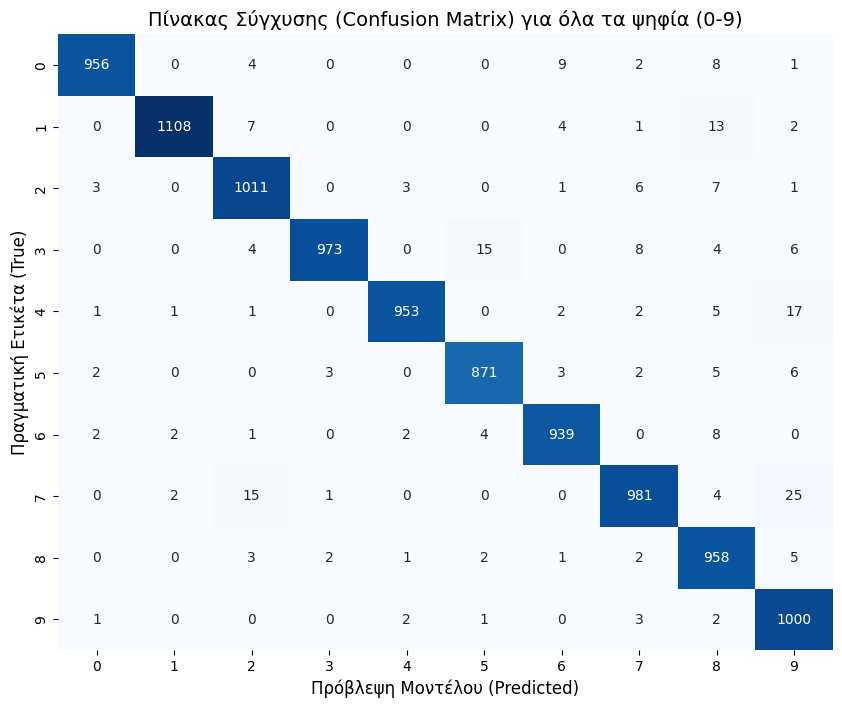

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_classifier_advanced(model, test_loaders):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        # Περνάμε μέσα από ΟΛΑ τα test sets (από το Task 1 μέχρι το Task 5)
        for loader in test_loaders:
            for data, target in loader:
                data = data.to(device)
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)

                # Αποθήκευση στο CPU για τον υπολογισμό των μετρικών
                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(target.numpy())

    print("\n=== ΑΝΑΛΥΤΙΚΗ ΑΝΑΦΟΡΑ ΤΑΞΙΝΟΜΗΣΗΣ (CLASSIFIER METRICS) ===")
    # Εμφανίζει Precision, Recall, F1-Score για κάθε ψηφίο ξεχωριστά!
    print(classification_report(all_targets, all_preds, digits=4))

    # Σχεδιασμός Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Πίνακας Σύγχυσης (Confusion Matrix) για όλα τα ψηφία (0-9)', fontsize=14)
    plt.xlabel('Πρόβλεψη Μοντέλου (Predicted)', fontsize=12)
    plt.ylabel('Πραγματική Ετικέτα (True)', fontsize=12)
    plt.show()

# Καλούμε τη συνάρτηση με τον τελικό Scholar Classifier
evaluate_classifier_advanced(gr_classifier, test_loaders)

In [9]:
def calculate_continual_learning_metrics(accuracy_matrix):
    """
    accuracy_matrix: Μια λίστα από λίστες. Κάθε γραμμή είναι το τέλος ενός Task.
    Η στήλη είναι η ακρίβεια στο αντίστοιχο παλιό Task.
    """
    N = len(accuracy_matrix)
    forgetting = []
    bwt = []

    # Υπολογισμός για τα παλιά Tasks (j) μετά την εκμάθηση όλων των Tasks (N)
    for j in range(N - 1):
        # Βρίσκουμε την ΜΕΓΙΣΤΗ ακρίβεια που είχε πετύχει στο παρελθόν στο Task j
        max_acc_past = max([accuracy_matrix[i][j] for i in range(j, N - 1)])
        # Η τελική του ακρίβεια στο Task j στο τέλος της εκπαίδευσης
        final_acc = accuracy_matrix[N-1][j]

        # Forgetting = Πόσο έπεσε από την καλύτερή του επίδοση
        f_j = max_acc_past - final_acc
        forgetting.append(f_j)

        # Backward Transfer = Τελική απόδοση - Απόδοση αμέσως μόλις το έμαθε
        initial_acc = accuracy_matrix[j][j]
        bwt_j = final_acc - initial_acc
        bwt.append(bwt_j)

    avg_forgetting = sum(forgetting) / len(forgetting)
    avg_bwt = sum(bwt) / len(bwt)

    print("=== ΜΕΤΡΙΚΕΣ CONTINUAL LEARNING ===")
    print(f"Μέση Λήθη (Average Forgetting): {avg_forgetting:.2f}% (Ιδανικά θέλουμε να είναι κοντά στο 0%)")
    print(f"Μεταφορά Γνώσης (Backward Transfer): {avg_bwt:.2f}% (Αν είναι αρνητικό, δείχνει λήθη)")

# ΕΔΩ: Βάλε τα πραγματικά νούμερα που σου έβγαλε το output σου
# (από το τελευταίο screenshot που μου έστειλες με τα τέλεια αποτελέσματα).
# Είναι ένας τριγωνικός πίνακας.
my_results = [
    [100.00],                                         # Μετά το Task 1
    [99.24, 99.85],                                   # Μετά το Task 2
    [99.01, 98.73, 99.79],                            # Μετά το Task 3
    [97.87, 96.47, 98.88, 99.24],                     # Μετά το Task 4
    [97.12, 94.71, 94.08, 97.53, 98.94]               # Μετά το Task 5
]

calculate_continual_learning_metrics(my_results)

=== ΜΕΤΡΙΚΕΣ CONTINUAL LEARNING ===
Μέση Λήθη (Average Forgetting): 3.86% (Ιδανικά θέλουμε να είναι κοντά στο 0%)
Μεταφορά Γνώσης (Backward Transfer): -3.86% (Αν είναι αρνητικό, δείχνει λήθη)


Naive Sequential Training

In [10]:
class SimpleClassifier(nn.Module):
    def __init__(self):
        super(SimpleClassifier, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Το μοντέλο θα τρέξει σε: {device}")

model = SimpleClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS_PER_TASK = 3

def evaluate_model(model, test_loaders, current_task_idx):
    model.eval()
    accuracies = []
    with torch.no_grad():
        for i in range(current_task_idx + 1):
            correct = 0
            total = 0
            for data, target in test_loaders[i]:
                data, target = data.to(device), target.to(device)
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
            acc = 100 * correct / total
            accuracies.append(acc)
    return accuracies

Το μοντέλο θα τρέξει σε: cuda


In [11]:
print("\n--- Ξεκινάει η Εκπαίδευση (Naive Approach) ---")
naive_acc_matrix = []  # Αποθήκευση για τα τελικά plots
for task_idx, train_loader in enumerate(train_loaders):
    print(f"\nΕκπαίδευση στο Task {task_idx + 1} (Ψηφία {tasks[task_idx]})...")
    model.train()

    for epoch in range(EPOCHS_PER_TASK):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()

    accs = evaluate_model(model, test_loaders, task_idx)
    naive_acc_matrix.append(accs)  # Αποθήκευση για plots
    print(f"Αποτελέσματα μετά το Task {task_idx + 1}:")
    for i, acc in enumerate(accs):
        print(f" -> Ακρίβεια στο Task {i + 1}: {acc:.2f}%")


--- Ξεκινάει η Εκπαίδευση (Naive Approach) ---

Εκπαίδευση στο Task 1 (Ψηφία [0, 1])...
Αποτελέσματα μετά το Task 1:
 -> Ακρίβεια στο Task 1: 99.95%

Εκπαίδευση στο Task 2 (Ψηφία [2, 3])...
Αποτελέσματα μετά το Task 2:
 -> Ακρίβεια στο Task 1: 0.00%
 -> Ακρίβεια στο Task 2: 97.65%

Εκπαίδευση στο Task 3 (Ψηφία [4, 5])...
Αποτελέσματα μετά το Task 3:
 -> Ακρίβεια στο Task 1: 0.00%
 -> Ακρίβεια στο Task 2: 0.00%
 -> Ακρίβεια στο Task 3: 98.83%

Εκπαίδευση στο Task 4 (Ψηφία [6, 7])...
Αποτελέσματα μετά το Task 4:
 -> Ακρίβεια στο Task 1: 0.00%
 -> Ακρίβεια στο Task 2: 0.00%
 -> Ακρίβεια στο Task 3: 0.00%
 -> Ακρίβεια στο Task 4: 51.86%

Εκπαίδευση στο Task 5 (Ψηφία [8, 9])...
Αποτελέσματα μετά το Task 5:
 -> Ακρίβεια στο Task 1: 0.00%
 -> Ακρίβεια στο Task 2: 0.00%
 -> Ακρίβεια στο Task 3: 0.00%
 -> Ακρίβεια στο Task 4: 0.00%
 -> Ακρίβεια στο Task 5: 50.88%


Random Replay Buffer

In [12]:
class RandomReplayBuffer:
    def __init__(self, samples_per_task):
        self.samples_per_task = samples_per_task
        self.buffer_data = []
        self.buffer_targets = []

    def add_data(self, loader):
        all_data, all_targets = [], []
        for d, t in loader:
            all_data.append(d)
            all_targets.append(t)
        all_data = torch.cat(all_data)
        all_targets = torch.cat(all_targets)

        indices = torch.randperm(len(all_data))[:self.samples_per_task]
        self.buffer_data.append(all_data[indices])
        self.buffer_targets.append(all_targets[indices])

    def get_buffer_loader(self, batch_size):
        if len(self.buffer_data) == 0:
            return None
        b_data = torch.cat(self.buffer_data)
        b_targets = torch.cat(self.buffer_targets)
        dataset = TensorDataset(b_data, b_targets)
        return DataLoader(dataset, batch_size=batch_size, shuffle=True)

model_replay = SimpleClassifier().to(device)
optimizer_replay = optim.Adam(model_replay.parameters(), lr=0.001)

buffer = RandomReplayBuffer(samples_per_task=1000)

In [13]:
print("\n--- Ξεκινάει η Εκπαίδευση με Buffer Replay ---")
buffer_acc_matrix = []  # Αποθήκευση για τα τελικά plots
for task_idx, train_loader in enumerate(train_loaders):
    print(f"\nΕκπαίδευση στο Task {task_idx + 1} (Ψηφία {tasks[task_idx]})...")
    model_replay.train()

    buffer_loader = buffer.get_buffer_loader(BATCH_SIZE)
    if buffer_loader is not None:
        buffer_iter = iter(buffer_loader)

    for epoch in range(EPOCHS_PER_TASK):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            if buffer_loader is not None:
                try:
                    mem_data, mem_target = next(buffer_iter)
                except StopIteration:
                    buffer_iter = iter(buffer_loader)
                    mem_data, mem_target = next(buffer_iter)

                mem_data, mem_target = mem_data.to(device), mem_target.to(device)
                data = torch.cat([data, mem_data])
                target = torch.cat([target, mem_target])

            optimizer_replay.zero_grad()
            outputs = model_replay(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer_replay.step()

    buffer.add_data(train_loader)

    accs = evaluate_model(model_replay, test_loaders, task_idx)
    buffer_acc_matrix.append(accs)  # Αποθήκευση για plots
    print(f"Αποτελέσματα μετά το Task {task_idx + 1}:")
    for i, acc in enumerate(accs):
        print(f" -> Ακρίβεια στο Task {i + 1}: {acc:.2f}%")


--- Ξεκινάει η Εκπαίδευση με Buffer Replay ---

Εκπαίδευση στο Task 1 (Ψηφία [0, 1])...
Αποτελέσματα μετά το Task 1:
 -> Ακρίβεια στο Task 1: 99.91%

Εκπαίδευση στο Task 2 (Ψηφία [2, 3])...
Αποτελέσματα μετά το Task 2:
 -> Ακρίβεια στο Task 1: 98.30%
 -> Ακρίβεια στο Task 2: 97.94%

Εκπαίδευση στο Task 3 (Ψηφία [4, 5])...
Αποτελέσματα μετά το Task 3:
 -> Ακρίβεια στο Task 1: 97.54%
 -> Ακρίβεια στο Task 2: 92.26%
 -> Ακρίβεια στο Task 3: 97.81%

Εκπαίδευση στο Task 4 (Ψηφία [6, 7])...
Αποτελέσματα μετά το Task 4:
 -> Ακρίβεια στο Task 1: 96.03%
 -> Ακρίβεια στο Task 2: 90.06%
 -> Ακρίβεια στο Task 3: 93.86%
 -> Ακρίβεια στο Task 4: 97.08%

Εκπαίδευση στο Task 5 (Ψηφία [8, 9])...
Αποτελέσματα μετά το Task 5:
 -> Ακρίβεια στο Task 1: 96.74%
 -> Ακρίβεια στο Task 2: 87.51%
 -> Ακρίβεια στο Task 3: 86.29%
 -> Ακρίβεια στο Task 4: 93.50%
 -> Ακρίβεια στο Task 5: 95.31%


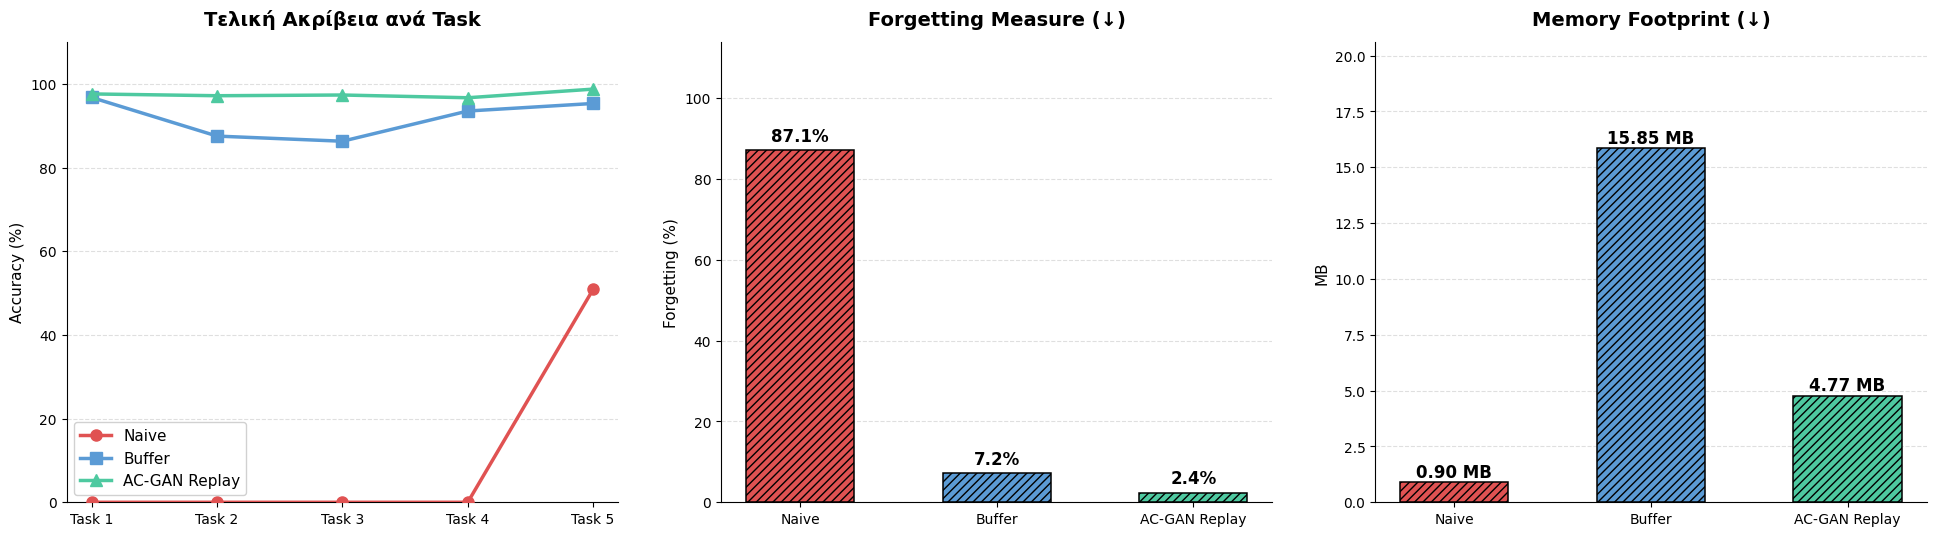

Plot αποθηκεύτηκε ως: continual_learning_comparison.png


In [14]:
# ════════════════════════════════════════════════════════════════════════════
#  ΣΥΓΚΡΙΤΙΚΑ PLOTS — Τελική Ακρίβεια | Forgetting | Memory Footprint
#  (Ακριβώς όπως η εικόνα αναφοράς)
# ════════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Βοηθητική: pad για ελλιπείς γραμμές ───────────────────────────────────
def pad_matrix(mat, n=5):
    padded = []
    for row in mat:
        padded.append(list(row) + [np.nan] * (n - len(row)))
    return padded

# ── Μετρική Forgetting ──────────────────────────────────────────────────────
def avg_forgetting(mat):
    """Μέση πτώση από το μέγιστο που πετύχαμε στο κάθε Task."""
    n = len(mat)
    f_vals = []
    for j in range(n - 1):          # για κάθε παλιό task j
        peak = max(mat[i][j] for i in range(j, n - 1))
        drop = peak - mat[n - 1][j]
        f_vals.append(drop)
    return np.mean(f_vals) if f_vals else 0.0

# ── Μετρική Memory Footprint ────────────────────────────────────────────────
def memory_mb(model):
    """Παράμετροι μοντέλου σε MB (float32)."""
    params = sum(p.numel() for p in model.parameters())
    return (params * 4) / (1024 ** 2)

# ── Συγκέντρωση δεδομένων ───────────────────────────────────────────────────
naive_mat  = pad_matrix(naive_acc_matrix)
buf_mat    = pad_matrix(buffer_acc_matrix)
gr_mat     = pad_matrix(gr_acc_matrix)

# Τελική γραμμή: ακρίβεια ανά task μετά το Task 5
final_naive  = naive_mat[-1]
final_buf    = buf_mat[-1]
final_gr     = gr_mat[-1]

# Forgetting (%)
forg_naive = avg_forgetting(naive_mat)
forg_buf   = avg_forgetting(buf_mat)
forg_gr    = avg_forgetting(gr_mat)

# Memory (MB) — Naive & GR από μοντέλα, Buffer προσθέτει raw images
mem_naive  = memory_mb(model)
mem_buf    = memory_mb(model_replay) + (5 * 1000 * 28 * 28 * 4) / (1024 ** 2)
mem_gr     = memory_mb(gr_classifier) + memory_mb(gr_G)

# ── Χρώματα & ρυθμίσεις (ακριβώς όπως η εικόνα αναφοράς) ──────────────────
C_NAIVE  = "#E05252"   # κόκκινο
C_BUF    = "#5B9BD5"   # γαλάζιο
C_GR     = "#4EC9A0"   # πράσινο-τιρκουάζ

HATCH    = "////"
EDGE     = "black"
FONTSIZE_TITLE  = 14
FONTSIZE_LABEL  = 11
FONTSIZE_VAL    = 12

x_tasks  = ["Task 1", "Task 2", "Task 3", "Task 4", "Task 5"]
methods  = ["Naive", "Buffer", "AC-GAN Replay"]
colors   = [C_NAIVE, C_BUF, C_GR]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor("white")

# ── PLOT 1: Τελική Ακρίβεια ανά Task ──────────────────────────────────────
ax = axes[0]
ax.plot(x_tasks, final_naive, color=C_NAIVE, marker="o",  linewidth=2.5,
        markersize=8, label="Naive",         zorder=3)
ax.plot(x_tasks, final_buf,   color=C_BUF,   marker="s",  linewidth=2.5,
        markersize=8, label="Buffer",        zorder=3)
ax.plot(x_tasks, final_gr,    color=C_GR,    marker="^",  linewidth=2.5,
        markersize=8, label="AC-GAN Replay", zorder=3)

ax.set_title("Τελική Ακρίβεια ανά Task", fontsize=FONTSIZE_TITLE, fontweight="bold", pad=12)
ax.set_ylabel("Accuracy (%)", fontsize=FONTSIZE_LABEL)
ax.set_ylim(0, 110)
ax.set_yticks(range(0, 110, 20))
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.spines[["top","right"]].set_visible(False)
ax.legend(fontsize=FONTSIZE_LABEL, framealpha=0.9)

# ── PLOT 2: Forgetting Measure ──────────────────────────────────────────────
ax = axes[1]
f_vals = [forg_naive, forg_buf, forg_gr]
bars   = ax.bar(methods, f_vals, color=colors, edgecolor=EDGE,
                linewidth=1.1, hatch=HATCH, width=0.55, zorder=3)

for bar, v in zip(bars, f_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.2,
            f"{v:.1f}%",
            ha="center", va="bottom",
            fontsize=FONTSIZE_VAL, fontweight="bold", color="black")

ax.set_title("Forgetting Measure (↓)", fontsize=FONTSIZE_TITLE, fontweight="bold", pad=12)
ax.set_ylabel("Forgetting (%)", fontsize=FONTSIZE_LABEL)
ax.set_ylim(0, max(f_vals) * 1.25 + 5)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.spines[["top","right"]].set_visible(False)

# ── PLOT 3: Memory Footprint ────────────────────────────────────────────────
ax = axes[2]
m_vals = [mem_naive, mem_buf, mem_gr]
bars   = ax.bar(methods, m_vals, color=colors, edgecolor=EDGE,
                linewidth=1.1, hatch=HATCH, width=0.55, zorder=3)

for bar, v in zip(bars, m_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f"{v:.2f} MB",
            ha="center", va="bottom",
            fontsize=FONTSIZE_VAL, fontweight="bold", color="black")

ax.set_title("Memory Footprint (↓)", fontsize=FONTSIZE_TITLE, fontweight="bold", pad=12)
ax.set_ylabel("MB", fontsize=FONTSIZE_LABEL)
ax.set_ylim(0, max(m_vals) * 1.3)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout(pad=3.0)
plt.savefig("continual_learning_comparison.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Plot αποθηκεύτηκε ως: continual_learning_comparison.png")
